In [3]:
adata.write('DLPFC_151508_07_1.h5ad', compression='gzip')

In [3]:
adata.write('DLPFC_151509_07_1.h5ad', compression='gzip')

In [3]:
adata.write('DLPFC_151510_07_1.h5ad', compression='gzip')

In [3]:
adata.write('DLPFC_151669_7_1.h5ad', compression='gzip')

In [3]:
adata.write('DLPFC_151670_7_1.h5ad', compression='gzip')

In [ ]:
import scanpy as sc

from SPAIR.utils import coor_transform, plotting
from SPAIR.alignment import get_transform,calculate_alignment_score#,get_transform1


adatas = sc.read_h5ad('D:/biancheng/SPAIR-master/DLPFC_151670_7_1.h5ad')
adata_list = []
for i in range(2):
    adata_list.append(adatas[str(i) == adatas.obs['batch']])

>>> INFO: dst slice id: 0, src slice id: 1
>>> INFO: dst coordination shape: (1245, 2)
>>> INFO: src coordination shape: (640, 2)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
>>> INFO: current distance: 89.1315867564654


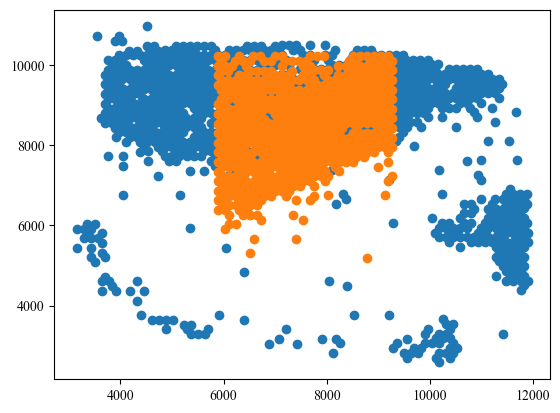

{0: array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]),
 1: array([[ 1.00000000e+00, -2.29959531e-17,  1.40672091e+01],
        [ 1.18614763e-16,  1.00000000e+00,  2.83463237e+01],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])}

In [5]:
dst_id = 0
pyramidal_label_id = [3,6,5]
src_id_list = list(range(0, 2))

M = get_transform(adata_list, dst_id, src_id_list, pyramidal_label_id,tolerance=1e-3,threshold=200)
M

[[1.0168e+04 4.4530e+03 9.6280e+03 ... 5.2100e+03 5.0080e+03 6.6700e+03]
 [8.5710e+03 9.6350e+03 4.2580e+03 ... 9.7570e+03 7.9600e+03 3.4130e+03]
 [1.0000e+00 1.0000e+00 1.0000e+00 ... 1.0000e+00 1.0000e+00 1.0000e+00]]
['Layer_4' 'Layer_6' 'Layer_3' ... 'Layer_6' 'Layer_5' 'Layer_3']
0.577472841623785


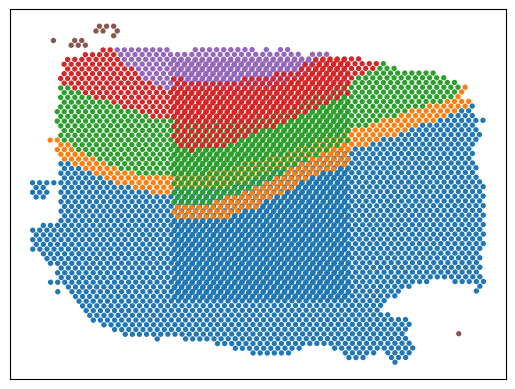

In [7]:
coor_list = [coor_transform(adata_list[src_id].obsm['spatial'], M[src_id]) for src_id in src_id_list]
label_list = [adata_list[src_id].obs['cluster'].to_numpy() for src_id in src_id_list]
print(coor_list[0])
print(label_list[0])

plotting(coor_list, label_list, spot_size=8)
score= calculate_alignment_score(coor_list, label_list, knears=1)
print (score)

In [ ]:
import numpy as np
from scipy.spatial import cKDTree
def evaluation(src_cor, tgt_cor, src_exp, tgt_exp, src_cell_type, tgt_cell_type):
    kd_tree = cKDTree(src_cor)
    distances, indices = kd_tree.query(tgt_cor, k=1)
    if hasattr(src_exp, 'toarray'):
        src_exp = src_exp.toarray()
    if hasattr(tgt_exp, 'toarray'):
        tgt_exp = tgt_exp.toarray()
    
    cell_pcc_values = []
    
   
    for i in range(tgt_exp.shape[0]):
        
        tgt_vector = tgt_exp[i, :]
        src_vector = src_exp[indices[i], :]
        
        
        pcc = np.corrcoef(tgt_vector, src_vector)[0, 1]
        
        
        cell_pcc_values.append(pcc)
    
    
    pcc_median = np.median(cell_pcc_values)
    
   
    cri = np.mean((tgt_cell_type == src_cell_type[indices]) + 0)
    
    return cell_pcc_values, pcc_median, cri

In [10]:
cell_pcc_values, pcc_median, cri=evaluation(coor_list[0].T, coor_list[1].T, adatas[str(0) == adatas.obs['batch']].X, adatas[str(1) == adatas.obs['batch']].X, np.array(label_list[0]), np.array(label_list[1]))

In [ ]:
#151508
cri

0.8601134215500945

In [52]:
#151509
cri

0.6871455576559546

In [21]:
#151510
cri

0.7117202268431002

In [8]:
#151669
cri

0.8117647058823529

In [11]:
#151670
cri

0.7349019607843137

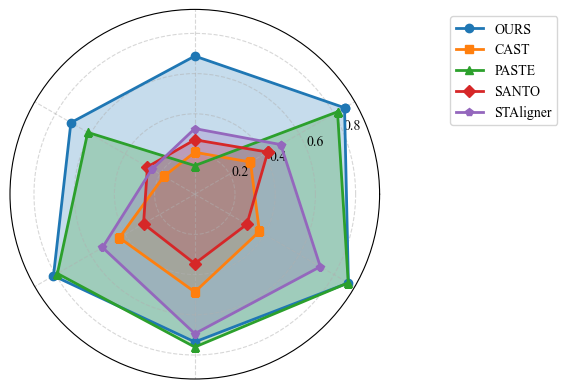

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


#labels = np.array(['151508', '151509', '151510', '151669', '151670','151672']) 
labels = np.array(['', '', '', '', '',''])  

data1 = [0.8601 , 0.6871 , 0.7117, 0.8118 , 0.7349 , 0.8823,0.8601]  
data2 = [0.3198 , 0.2086 , 0.1778,  0.4335 , 0.4863 , 0.3711,0.3198]  
data3=[0.8197 , 0.1421 , 0.6151 , 0.7892 , 0.7604 , 0.8815,0.8197]
data4=[0.4191,  0.2708 , 0.2719 , 0.2945 , 0.3454 , 0.2992,0.4191]
data5=[0.4936 , 0.3264 , 0.2469 , 0.5302 , 0.6938, 0.7210,0.4936]

rotation_deg = 30  
rotation_rad = np.radians(rotation_deg) 

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles = [angle + rotation_rad for angle in angles]  
angles += angles[:1]  

fig = plt.figure()
ax = fig.add_subplot(111, polar=True)  


ax.plot(angles, data1, 'o-', linewidth=2, label='OURS')  
ax.fill(angles, data1, alpha=0.25)  


ax.plot(angles, data2, 's-', linewidth=2, label='CAST')  
ax.fill(angles, data2, alpha=0.25)  
ax.plot(angles, data3, '^-', linewidth=2, label='PASTE')  
ax.fill(angles, data3, alpha=0.25) 
ax.plot(angles, data4, 'D-', linewidth=2, label='SANTO')  
ax.fill(angles, data4, alpha=0.25)   
ax.plot(angles, data5, 'p-', linewidth=2, label='STAligner')  
ax.fill(angles, data5, alpha=0.25)  

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=8 )  
ax.grid(True, linestyle='--', alpha=0.5) 

ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.0)) 

plt.title('')
plt.savefig('DLPFC_leida.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import scanpy as sc

from train_integrate import train_integration
import st_datasets as stds

# load data

ids = ['151507', '151508', '151509', '151510']
#ids = [7,12]#第8张和最后一张


adata_list = [stds.get_data(stds.get_dlpfc_data, id=id)[0] for id in ids]
print (adata_list)
#adata_list = [stds.get_data(stds.get_dlpfc_data, id=i)[0] for i in range(4)]
#print (adata_list)
adatas = sc.concat(adata_list, label='batch')
print(adatas)
adatas = adatas[:, adata_list[-1].var['highly_variable']]
print(adatas)
# train SPAIR
adatas = train_integration(adata=adatas, radius=150)

>>> INFO: Use local data.
>>> INFO: dataset name: dorsolateral prefrontal cortex (DLPFC), slice: 151507, size: (4226, 33538), cluster: 6.(0.540s)
>>> INFO: Use local data.
>>> INFO: dataset name: dorsolateral prefrontal cortex (DLPFC), slice: 151508, size: (4384, 33538), cluster: 6.(0.423s)
>>> INFO: Use local data.
>>> INFO: dataset name: dorsolateral prefrontal cortex (DLPFC), slice: 151509, size: (4789, 33538), cluster: 6.(0.518s)
>>> INFO: Use local data.
>>> INFO: dataset name: dorsolateral prefrontal cortex (DLPFC), slice: 151510, size: (4634, 33538), cluster: 6.(0.489s)
[AnnData object with n_obs × n_vars = 4226 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial', AnnData object with n_obs × n_vars = 4384 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster'
    var: 'gen

  0%|          | 0/500 [00:00<?, ?it/s]

>>> INFO: Finish finding mmn pairs, find 912907 mnn node pairs(3.481s)!


 20%|██        | 100/500 [09:18<40:13,  6.03s/it]

>>> INFO: Finish finding mmn pairs, find 1458387 mnn node pairs(3.900s)!


...

 60%|██████    | 300/500 [29:27<19:26,  5.83s/it]

>>> INFO: Finish finding mmn pairs, find 1828341 mnn node pairs(4.145s)!


 80%|████████  | 400/500 [39:26<09:57,  5.97s/it]

>>> INFO: Finish finding mmn pairs, find 1868967 mnn node pairs(4.064s)!


100%|██████████| 500/500 [49:40<00:00,  5.96s/it]


In [2]:
adatas.write('DLPFC_151507_510_aliment.h5ad', compression='gzip')

In [3]:
import st_datasets as stds
adata = stds.cl.mclust_R(adatas, used_obsm='embedding', num_cluster=5)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [5]:
adata.write('DLPFC_151507_510_aliment.h5ad', compression='gzip')

In [ ]:
import scanpy as sc

from SPAIR.utils import coor_transform, plotting
from SPAIR.alignment import get_transform,calculate_alignment_score#,get_transform1


adatas = sc.read_h5ad('DLPFC_151507_510_aliment.h5ad')
adata_list = []
for i in range(4):
    adata_list.append(adatas[str(i) == adatas.obs['batch']])

>>> INFO: dst slice id: 0, src slice id: 1
>>> INFO: dst coordination shape: (1232, 2)
>>> INFO: src coordination shape: (1286, 2)
>>> INFO: current distance: 59.910697413069016


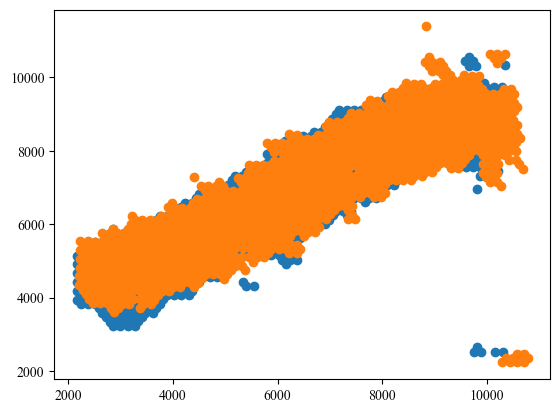

>>> INFO: dst slice id: 0, src slice id: 2
>>> INFO: dst coordination shape: (1232, 2)
>>> INFO: src coordination shape: (1592, 2)
>>> INFO: current distance: 324.4075059050281


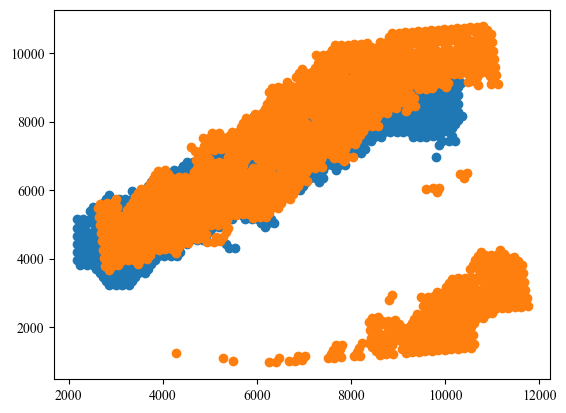

>>> INFO: dst slice id: 0, src slice id: 3
>>> INFO: dst coordination shape: (1232, 2)
>>> INFO: src coordination shape: (1596, 2)
>>> INFO: current distance: 374.17038648683734


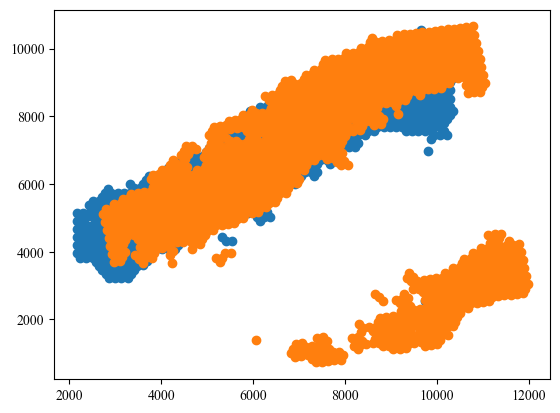

{0: array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]),
 1: array([[ 9.99687306e-01,  2.50057938e-02, -6.29696456e+01],
        [-2.50057938e-02,  9.99687306e-01, -9.87755083e+01],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]]),
 2: array([[ 9.95217610e-01, -9.76826968e-02,  1.15590217e+03],
        [ 9.76826968e-02,  9.95217610e-01, -2.14461440e+03],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]]),
 3: array([[ 9.89066156e-01, -1.47472502e-01,  1.72160922e+03],
        [ 1.47472502e-01,  9.89066156e-01, -2.79912623e+03],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])}

In [21]:
dst_id = 0
pyramidal_label_id = 2
src_id_list = list(range(0, 4))

M = get_transform(adata_list, dst_id, src_id_list, pyramidal_label_id,tolerance=1e-4,threshold=500)
M

[array([[3.276e+03, 9.178e+03, 5.133e+03, ..., 4.218e+03, 4.017e+03,
        5.683e+03],
       [2.514e+03, 8.520e+03, 2.878e+03, ..., 9.703e+03, 7.906e+03,
        3.359e+03],
       [1.000e+00, 1.000e+00, 1.000e+00, ..., 1.000e+00, 1.000e+00,
        1.000e+00]]), array([[9.31986239e+03, 5.13604423e+03, 3.63115620e+03, ...,
        4.14509763e+03, 5.18174409e+03, 5.69790004e+03],
       [8.25521157e+03, 2.71609922e+03, 9.45783824e+03, ...,
        7.76945878e+03, 1.11015785e+04, 3.18319562e+03],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00]]), array([[9.53979511e+03, 6.01950976e+03, 3.69548232e+03, ...,
        4.41499997e+03, 5.04980281e+03, 6.52457711e+03],
       [7.36783913e+03, 1.31200681e+03, 7.88341659e+03, ...,
        6.25491288e+03, 9.71748148e+03, 1.84790603e+03],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00]]), array([[9.57218199e+0

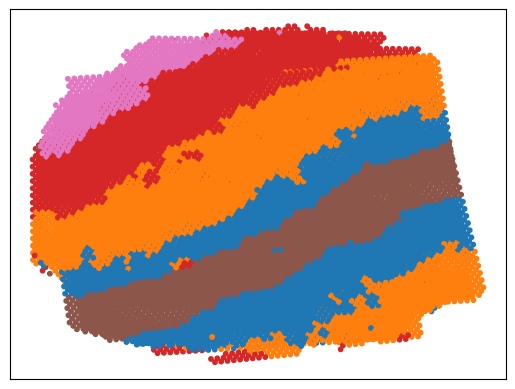

In [22]:
coor_list = [coor_transform(adata_list[src_id].obsm['spatial'], M[src_id]) for src_id in src_id_list]
label_list = [adata_list[src_id].obs['mclust'].to_numpy() for src_id in src_id_list]
print(coor_list)
print(label_list)

plotting(coor_list, label_list,spot_size=10,)# save_path='mouse_spleen_1-2_RNA_aliment.pdf',)
score= calculate_alignment_score(coor_list, label_list, knears=1)
print (score)

>>> INFO: matching score: 0.9398958826313298


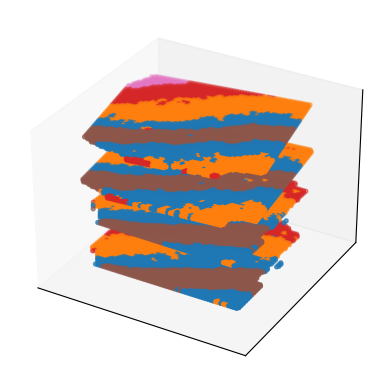

In [ ]:
import numpy as np
src = adatas['0' == adatas.obs['batch']]
dst = adatas['1' == adatas.obs['batch']]
from SPAIR.utils import find_similar_index, plotting
_, order = find_similar_index(
    src.obsm['embedding'],
    dst.obsm['embedding'],
)
matching_score = np.sum(src.obs['mclust'].to_numpy() == dst[order.reshape(-1)].obs['mclust'].to_numpy()) / src.X.shape[0]

print(f'>>> INFO: matching score:', matching_score)
plotting(
    coor_list,
    label_list,
    save_path='DLPFC_151507_510_aliment_3D.pdf',
    dims='3d',
    
    spot_size=8,
    line_list=np.hstack([np.arange(src.shape[0]).reshape(-1, 1), order]).reshape(1, -1, 2)[:, np.random.randint(low=5, high=src.shape[0], size=50), :],
    
)

In [ ]:
import scanpy as sc

from train_integrate import train_integration
import st_datasets as stds

# load data

ids = ['151669', '151670', '151671', '151672']



adata_list = [stds.get_data(stds.get_dlpfc_data, id=id)[0] for id in ids]
print (adata_list)
#adata_list = [stds.get_data(stds.get_dlpfc_data, id=i)[0] for i in range(4)]
#print (adata_list)
adatas = sc.concat(adata_list, label='batch')
print(adatas)
adatas = adatas[:, adata_list[-1].var['highly_variable']]
print(adatas)
# train SPAIR
adatas = train_integration(adata=adatas, radius=150)

>>> INFO: Use local data.
>>> INFO: dataset name: dorsolateral prefrontal cortex (DLPFC), slice: 151669, size: (3661, 33538), cluster: 6.(0.579s)
>>> INFO: Use local data.
>>> INFO: dataset name: dorsolateral prefrontal cortex (DLPFC), slice: 151670, size: (3498, 33538), cluster: 6.(0.527s)
>>> INFO: Use local data.
>>> INFO: dataset name: dorsolateral prefrontal cortex (DLPFC), slice: 151671, size: (4110, 33538), cluster: 6.(0.600s)
>>> INFO: Use local data.
>>> INFO: dataset name: dorsolateral prefrontal cortex (DLPFC), slice: 151672, size: (4015, 33538), cluster: 6.(0.603s)
[AnnData object with n_obs × n_vars = 3661 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial', AnnData object with n_obs × n_vars = 3498 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster'
    var: 'gen

  0%|          | 0/500 [00:00<?, ?it/s]

>>> INFO: Finish finding mmn pairs, find 783163 mnn node pairs(3.275s)!


 20%|██        | 100/500 [07:56<32:30,  4.88s/it]

>>> INFO: Finish finding mmn pairs, find 1304089 mnn node pairs(3.233s)!


...

 60%|██████    | 300/500 [25:29<17:30,  5.25s/it]

>>> INFO: Finish finding mmn pairs, find 1588478 mnn node pairs(3.585s)!


 80%|████████  | 400/500 [33:58<07:55,  4.75s/it]

>>> INFO: Finish finding mmn pairs, find 1619162 mnn node pairs(3.343s)!


100%|██████████| 500/500 [42:33<00:00,  5.11s/it]


In [2]:
import st_datasets as stds
adata = stds.cl.mclust_R(adatas, used_obsm='embedding', num_cluster=5)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [3]:
adata.write('DLPFC_151669_672_aliment.h5ad', compression='gzip')

In [ ]:
import scanpy as sc

from SPAIR.utils import coor_transform, plotting
from SPAIR.alignment import get_transform,calculate_alignment_score#,get_transform1


adatas = sc.read_h5ad('DLPFC_151669_672_aliment.h5ad')
adata_list = []
for i in range(4):
    adata_list.append(adatas[str(i) == adatas.obs['batch']])

>>> INFO: dst slice id: 0, src slice id: 1
>>> INFO: dst coordination shape: (1223, 2)
>>> INFO: src coordination shape: (1263, 2)
>>> INFO: current distance: 42.961404218842674


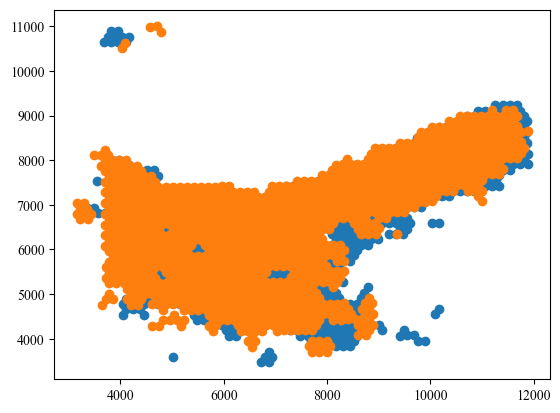

>>> INFO: dst slice id: 0, src slice id: 2
>>> INFO: dst coordination shape: (1223, 2)
>>> INFO: src coordination shape: (1438, 2)
>>> INFO: current distance: 120.62697152169886


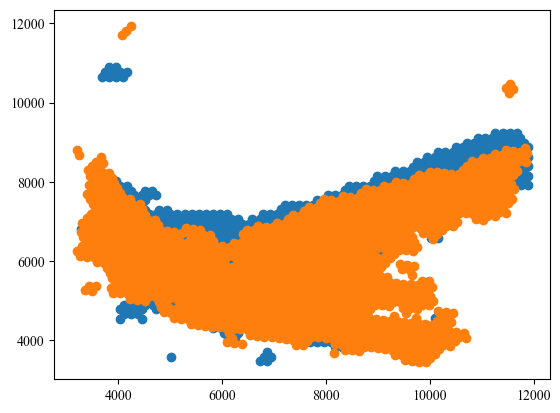

>>> INFO: dst slice id: 0, src slice id: 3
>>> INFO: dst coordination shape: (1223, 2)
>>> INFO: src coordination shape: (1427, 2)
>>> INFO: current distance: 166.5516994359695


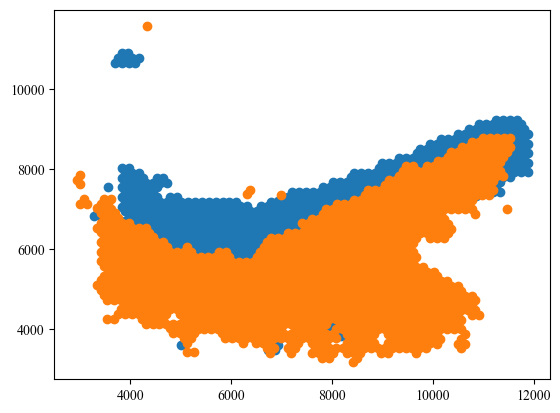

{0: array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]),
 1: array([[ 9.99994080e-01, -3.44099252e-03,  2.78386415e+01],
        [ 3.44099252e-03,  9.99994080e-01, -9.29659870e+01],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]]),
 2: array([[ 9.91108352e-01,  1.33057261e-01, -1.01364405e+03],
        [-1.33057261e-01,  9.91108352e-01,  1.38748500e+03],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]]),
 3: array([[ 9.99984508e-01,  5.56625467e-03, -3.03086444e+02],
        [-5.56625467e-03,  9.99984508e-01,  4.95095650e+02],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])}

In [5]:
dst_id = 0
pyramidal_label_id = 2
src_id_list = list(range(0, 4))

M = get_transform(adata_list, dst_id, src_id_list, pyramidal_label_id,tolerance=1e-4,threshold=500)
M

[array([[1.0162e+04, 4.4460e+03, 9.6200e+03, ..., 5.2030e+03, 5.0000e+03,
        6.6620e+03],
       [8.5050e+03, 9.5710e+03, 4.1920e+03, ..., 9.6920e+03, 7.8950e+03,
        3.3470e+03],
       [1.0000e+00, 1.0000e+00, 1.0000e+00, ..., 1.0000e+00, 1.0000e+00,
        1.0000e+00]]), array([[1.01662857e+04, 4.44765832e+03, 9.64112990e+03, ...,
        5.20423403e+03, 5.00841869e+03, 6.68605505e+03],
       [8.51297128e+03, 9.55729971e+03, 4.19813868e+03, ...,
        9.68190382e+03, 7.88421938e+03, 3.34296523e+03],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00]]), array([[1.02586192e+04, 4.73429175e+03, 9.14742941e+03, ...,
        5.06135292e+03, 6.45651684e+03, 6.10243947e+03],
       [8.58764987e+03, 1.04048597e+04, 4.38412547e+03, ...,
        8.66991535e+03, 1.18697303e+04, 3.94134646e+03],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00]]), arr

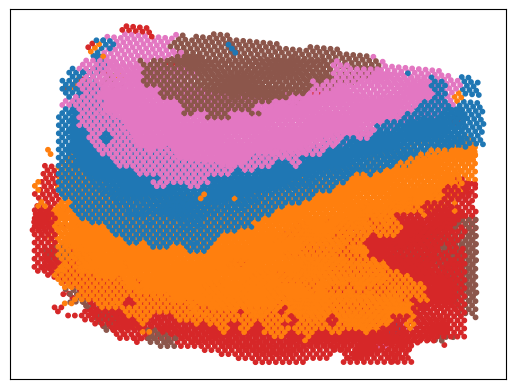

In [6]:
coor_list = [coor_transform(adata_list[src_id].obsm['spatial'], M[src_id]) for src_id in src_id_list]
label_list = [adata_list[src_id].obs['mclust'].to_numpy() for src_id in src_id_list]
print(coor_list)
print(label_list)

plotting(coor_list, label_list,spot_size=10,)# save_path='mouse_spleen_1-2_RNA_aliment.pdf',)
score= calculate_alignment_score(coor_list, label_list, knears=1)
print (score)

>>> INFO: matching score: 0.8981152690521715


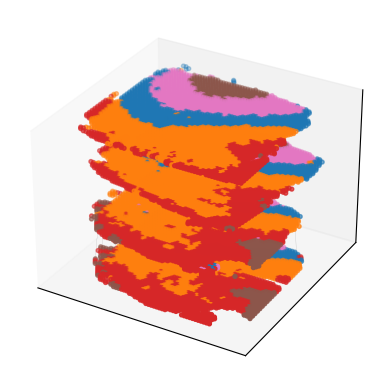

In [ ]:
import numpy as np
src = adatas['0' == adatas.obs['batch']]
dst = adatas['1' == adatas.obs['batch']]
from SPAIR.utils import find_similar_index, plotting
_, order = find_similar_index(
    src.obsm['embedding'],
    dst.obsm['embedding'],
)
matching_score = np.sum(src.obs['mclust'].to_numpy() == dst[order.reshape(-1)].obs['mclust'].to_numpy()) / src.X.shape[0]

print(f'>>> INFO: matching score:', matching_score)
plotting(
    coor_list,
    label_list,
    save_path='DLPFC_151669_672_aliment_3D.pdf',
    dims='3d',
    
    spot_size=8,
    line_list=np.hstack([np.arange(src.shape[0]).reshape(-1, 1), order]).reshape(1, -1, 2)[:, np.random.randint(low=5, high=src.shape[0], size=50), :],
    
)

In [ ]:
import scanpy as sc

from SPAIR.utils import coor_transform, plotting
from SPAIR.alignment import get_transform,calculate_alignment_score#,get_transform1


adatas = sc.read_h5ad('DLPFC_151673_676_aliment.h5ad')

In [3]:
import st_datasets as stds
adata = stds.cl.mclust_R(adatas, used_obsm='embedding', num_cluster=7)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [4]:
adata.write('DLPFC_151673_676_aliment.h5ad', compression='gzip')

In [ ]:
import scanpy as sc

from SPAIR.utils import coor_transform, plotting
from SPAIR.alignment import get_transform,calculate_alignment_score#,get_transform1


adatas = sc.read_h5ad('DLPFC_151673_676_aliment.h5ad')
adata_list = []
for i in range(4):
    adata_list.append(adatas[str(i) == adatas.obs['batch']])

>>> INFO: dst slice id: 0, src slice id: 1
>>> INFO: dst coordination shape: (392, 2)
>>> INFO: src coordination shape: (364, 2)
>>> INFO: current distance: 47.77959778172285


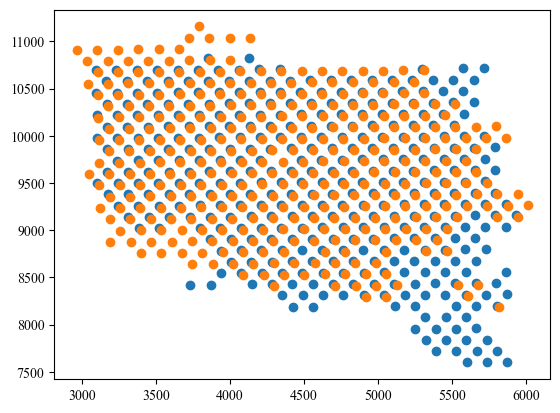

>>> INFO: dst slice id: 0, src slice id: 2
>>> INFO: dst coordination shape: (392, 2)
>>> INFO: src coordination shape: (370, 2)
>>> INFO: current distance: 70.82681751023283


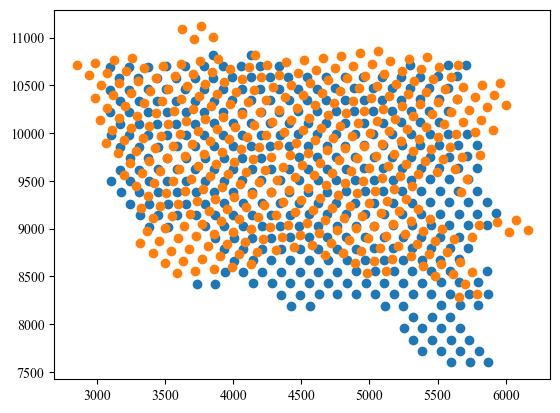

>>> INFO: dst slice id: 0, src slice id: 3
>>> INFO: dst coordination shape: (392, 2)
>>> INFO: src coordination shape: (327, 2)
>>> INFO: current distance: 66.6039810746568


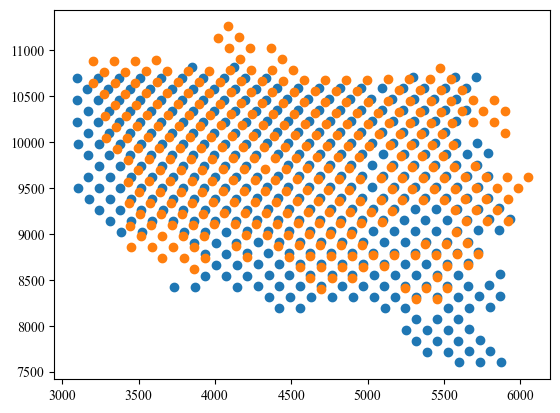

{0: array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]),
 1: array([[ 9.99998214e-01, -1.89013345e-03,  2.00896039e+01],
        [ 1.89013345e-03,  9.99998214e-01, -2.12223815e+02],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]]),
 2: array([[ 9.86142004e-01, -1.65903430e-01,  1.66275903e+03],
        [ 1.65903430e-01,  9.86142004e-01, -1.19446033e+03],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]]),
 3: array([[ 9.99914679e-01, -1.30627118e-02,  1.12151008e+02],
        [ 1.30627118e-02,  9.99914679e-01, -5.12933379e+01],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])}

In [6]:
dst_id = 0
pyramidal_label_id = 2
src_id_list = list(range(0, 4))

M = get_transform(adata_list, dst_id, src_id_list, pyramidal_label_id,tolerance=1e-4,threshold=500)
M

[array([[9.7910e+03, 5.7690e+03, 4.0680e+03, ..., 4.6310e+03, 5.5710e+03,
        6.3170e+03],
       [8.4680e+03, 2.8070e+03, 9.5050e+03, ..., 7.8310e+03, 1.1193e+04,
        3.2910e+03],
       [1.0000e+00, 1.0000e+00, 1.0000e+00, ..., 1.0000e+00, 1.0000e+00,
        1.0000e+00]]), array([[9.73694371e+03, 5.72764905e+03, 4.01299575e+03, ...,
        4.57915694e+03, 5.51180252e+03, 6.27473513e+03],
       [8.33915761e+03, 2.67156939e+03, 9.36434042e+03, ...,
        7.69240755e+03, 1.10551764e+04, 3.15560432e+03],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00]]), array([[5.01791927e+03, 9.81258043e+03, 3.99799993e+03, ...,
        4.72261945e+03, 4.83075432e+03, 5.19897433e+03],
       [1.97205381e+03, 8.89646298e+03, 8.96880666e+03, ...,
        9.21848355e+03, 7.41239472e+03, 1.08835875e+04],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00]]), arr

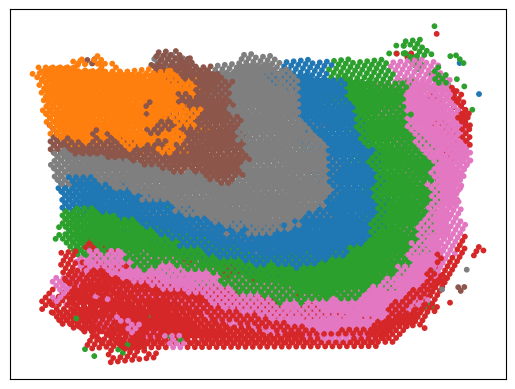

In [7]:
coor_list = [coor_transform(adata_list[src_id].obsm['spatial'], M[src_id]) for src_id in src_id_list]
label_list = [adata_list[src_id].obs['mclust'].to_numpy() for src_id in src_id_list]
print(coor_list)
print(label_list)

plotting(coor_list, label_list,spot_size=10, save_path='DLPFC_151673_676_aliment_2D.pdf',)
score= calculate_alignment_score(coor_list, label_list, knears=1)
print (score)

>>> INFO:CI matching score: 0.9090409453146469


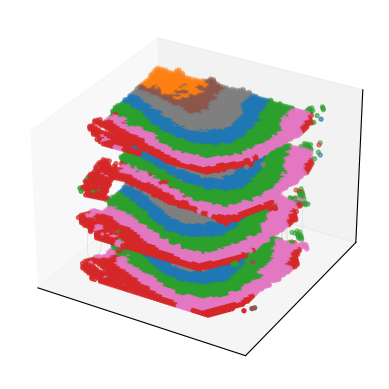

In [ ]:
import numpy as np
src = adatas['0' == adatas.obs['batch']]
dst = adatas['1' == adatas.obs['batch']]
from SPAIR.utils import find_similar_index, plotting
_, order = find_similar_index(
    src.obsm['embedding'],
    dst.obsm['embedding'],
)
matching_score = np.sum(src.obs['mclust'].to_numpy() == dst[order.reshape(-1)].obs['mclust'].to_numpy()) / src.X.shape[0]

print(f'>>> INFO:CI matching score:', matching_score)
plotting(
    coor_list,
    label_list,
    save_path='DLPFC_151673_676_aliment_3D.pdf',
    dims='3d',
    
    spot_size=8,
    line_list=np.hstack([np.arange(src.shape[0]).reshape(-1, 1), order]).reshape(1, -1, 2)[:, np.random.randint(low=5, high=src.shape[0], size=50), :],
    
)